# 04 — Walk-Forward Backtesting

**Problem:** The outcome of NB_03 is basically that the modell does not suffiecently capture away wins.

**Question:** The dataset was split in 2019. The model might be correct for historsical games in the test data but maybe some factors changed in the last 5 seasons.  

**Aim:** Now I want to train the model in a loop. So I model train on everything before, predict that season, repeat. 

How would my model have done *historically*? I simulate standing at the start of each season, training on everything before, and predicting the upcoming season:

    predict season N    <-  train on all seasons < N
    predict season N+1  <-  train on all seasons <= N
    ...

This shwos me the stability of the model over time. I expect a drift as the playstyle in the 60s is different than today.


## 1. Setup

In [1]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
import xgboost as xgb

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

df = pd.read_parquet(Path("..") / "data" / "processed" / "games_with_features.parquet")

# same as NB_03
feature_cols = [
    "home_elo_pre", "away_elo_pre", "elo_diff",
    "h2h_home_winrate_last5",
    "home_win_rate_last_5", "home_win_rate_last_10", "home_win_rate_last_20",
    "away_win_rate_last_5", "away_win_rate_last_10", "away_win_rate_last_20",
    "win_rate_diff_5", "win_rate_diff_10", "win_rate_diff_20",
    "home_avg_margin_last_5", "home_avg_margin_last_10", "home_avg_margin_last_20",
    "away_avg_margin_last_5", "away_avg_margin_last_10", "away_avg_margin_last_20",
    "margin_diff_5", "margin_diff_10", "margin_diff_20",
    "home_days_since_last_game", "away_days_since_last_game",
    "home_is_back_to_back", "away_is_back_to_back", "rest_diff",
]


TARGET = "home_win"

df = df.dropna(subset=feature_cols).sort_values("gameDate").reset_index(drop=True)
print(f"Usable: {len(df):,} games, seasons {df.season.min()} - {df.season.max()}")

Usable: 70,265 games, seasons 1946 - 2025


## 2. Forward loop

I am starting with 1960 such that the model has a few seasons of training.

In [2]:
FIRST_TEST_SEASON = 1960
MIN_TRAIN_SIZE = 500   # game that need to be analysed before prediction. Just making sure that we have a statistic and not 8 games

all_preds = []        # predictions per season
season_metrics = []   # metrics per season

seasons_to_test = sorted(df[df.season >= FIRST_TEST_SEASON].season.unique()) # sorting the seasons
print(f" backtest {len(seasons_to_test)} seasons ({seasons_to_test[0]} - {seasons_to_test[-1]})")

 backtest 66 seasons (1960 - 2025)


In [3]:
 # looping over seasons
for season in seasons_to_test:
    train = df[df.season < season ]  # train on everything before the season
    test = df[df.season == season] # only test the games in this season
    
    if len(train) < MIN_TRAIN_SIZE or len(test) == 0:   
        continue # skip if not enough training data

   
    X_train, y_train = train[feature_cols], train[TARGET] # split feature, target
    X_test, y_test = test[feature_cols], test[TARGET]

    # fresh XGBoost model trained from scratch each season
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, # adding randomness - important! 90% caltures most but makes the model more stable
        eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0,
    )
    model.fit(X_train, y_train)  # fit
    proba = model.predict_proba(X_test)[:, 1]      # Proba home win - X_test [P(away], P(home)]
    pred = (proba >= 0.5).astype(int)              # 0 or 1 - win or lose 

    # store metrics for this season
    season_metrics.append({
        "season": season,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, pred),
        "log_loss": log_loss(y_test, proba, labels=[0, 1]),
        "brier":    brier_score_loss(y_test, proba),
        "auc":      roc_auc_score(y_test, proba) if y_test.nunique() == 2 else np.nan,
        "home_win_rate_actual": y_test.mean(),
    })

    # store the actual predictions per game for later analysis
    test_with_pred = test[["gameId", "gameDate", "season", "hometeamName", "awayteamName", "home_win"]].copy()
    test_with_pred["proba"] = proba
    test_with_pred["pred"] = pred
    all_preds.append(test_with_pred)

# stack everything into final dataframe
metrics_df = pd.DataFrame(season_metrics)
preds_df = pd.concat(all_preds, ignore_index=True)
print(f"{len(metrics_df)} seasons tested, {len(preds_df):,} games predicted in total")
metrics_df.tail(10).round(3)

66 seasons tested, 67,238 games predicted in total


,season,n_train,n_test,accuracy,log_loss,brier,auc,home_win_rate_actual
56,2016,57738,1293,0.643,0.632,0.220,0.688,0.583
57,2017,59031,1296,0.667,0.622,0.215,0.700,0.586
58,2018,60327,1296,0.658,0.621,0.215,0.697,0.590
59,2019,61623,1121,0.655,0.644,0.225,0.692,0.546
60,2020,62744,1153,0.607,0.666,0.236,0.673,0.544
61,2021,63897,1301,0.646,0.649,0.227,0.690,0.547
62,2022,65198,1298,0.645,0.651,0.229,0.652,0.582
63,2023,66496,1231,0.646,0.625,0.218,0.719,0.543
64,2024,67727,1294,0.658,0.619,0.215,0.723,0.548
65,2025,69021,1244,0.679,0.608,0.209,0.735,0.555


In [4]:
metrics_df.to_csv(Path("..") / "data" / "processed" / "backtest_metrics.csv", index=False)
print("Saved metrics")

Saved metrics


## 3. Performance over time

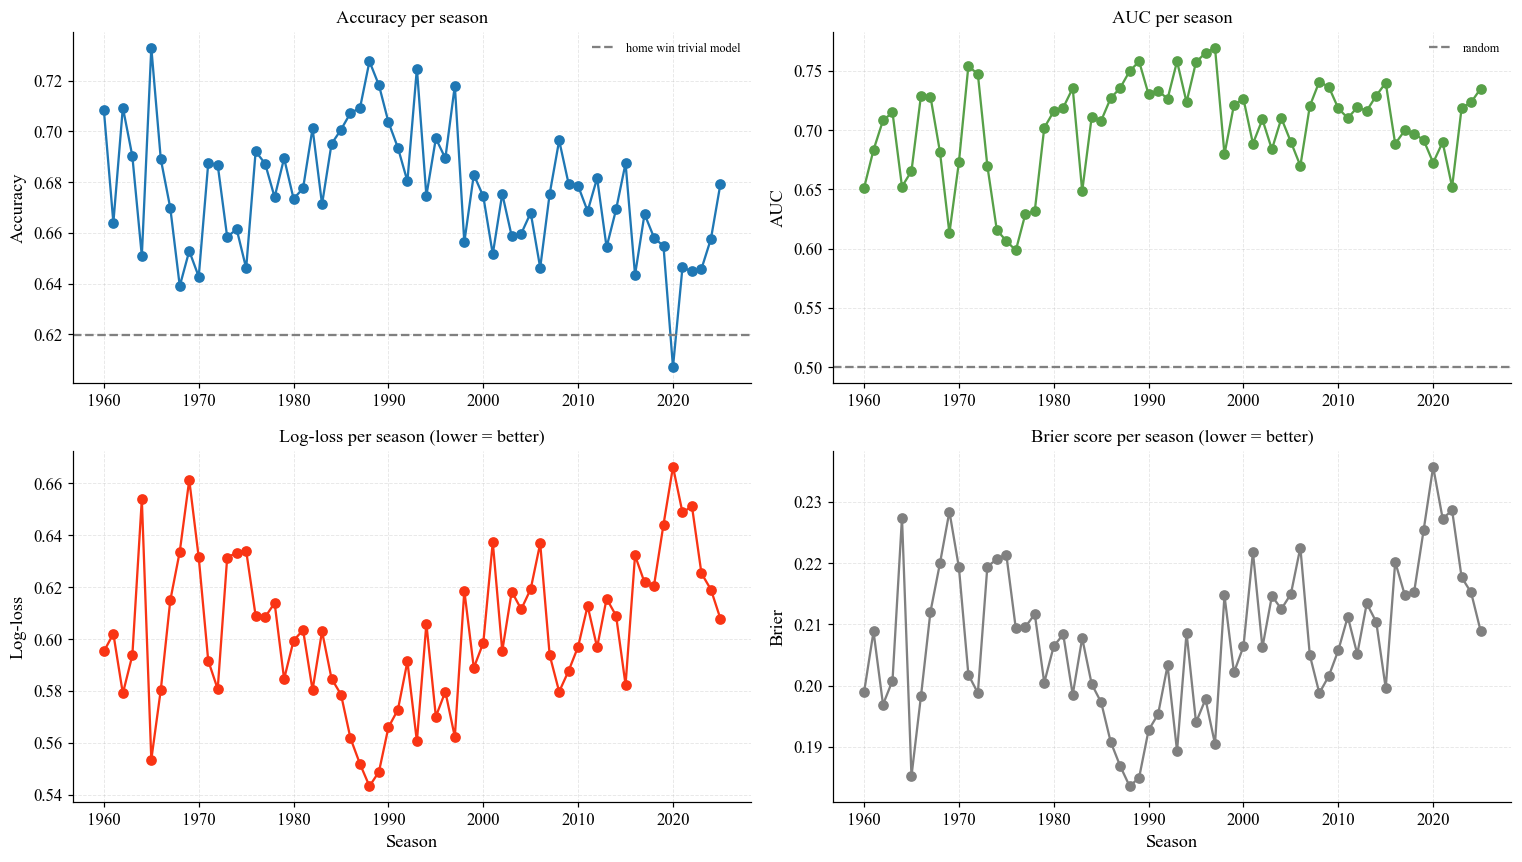

In [5]:
# plotting for drifts
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(metrics_df.season, metrics_df.accuracy, marker="o", color="#1f77b4")
axes[0, 0].axhline(metrics_df.home_win_rate_actual.mean(), color="gray", linestyle="--", label="home win trivial model")
axes[0, 0].set_title("Accuracy per season")
axes[0, 0].set_ylabel("Accuracy"); axes[0, 0].legend()

axes[0, 1].plot(metrics_df.season, metrics_df.auc, marker="o", color="#57A048")
axes[0, 1].axhline(0.5, color="gray", linestyle="--", label="random")
axes[0, 1].set_title("AUC per season")
axes[0, 1].set_ylabel("AUC"); axes[0, 1].legend()

axes[1, 0].plot(metrics_df.season, metrics_df.log_loss, marker="o", color="#f93414")
axes[1, 0].set_title("Log-loss per season (lower = better)")
axes[1, 0].set_ylabel("Log-loss"); axes[1, 0].set_xlabel("Season")

axes[1, 1].plot(metrics_df.season, metrics_df.brier, marker="o", color="gray")
axes[1, 1].set_title("Brier score per season (lower = better)")
axes[1, 1].set_ylabel("Brier"); axes[1, 1].set_xlabel("Season")

plt.tight_layout()
plt.show()

In [6]:
# average 
overall = pd.Series({
    'overall_accuracy': accuracy_score(preds_df.home_win, preds_df.pred),
    'overall_log_loss': log_loss(preds_df.home_win, preds_df.proba),
    'overall_brier':    brier_score_loss(preds_df.home_win, preds_df.proba),
    'overall_auc':      roc_auc_score(preds_df.home_win, preds_df.proba),
    'avg_season_acc':   metrics_df.accuracy.mean(),
    'best_season':      metrics_df.loc[metrics_df.accuracy.idxmax(), 'season'],
    'best_season_acc':  metrics_df.accuracy.max(),
    'worst_season':     metrics_df.loc[metrics_df.accuracy.idxmin(), 'season'],
    'worst_season_acc': metrics_df.accuracy.min(),
}).round(2)
overall

overall_accuracy       0.68
overall_log_loss       0.60
overall_brier          0.21
overall_auc            0.71
avg_season_acc         0.68
best_season         1965.00
best_season_acc        0.73
worst_season        2020.00
worst_season_acc       0.61
dtype: float64

**Plot Takeaway:**

- This model clearly beats the "always home" assumption baseline (except 2020 COVID).

- The average accuracy clearely shifts from ~70% in the 80s/90s to ~65% in the 2020s. **BUT** the model is **NOT WRING**. The AUC is staying stable around 0.70-0.74. This means that the home advantage itself shrunk overtime!

- Same story told by brier and log loss ... best in the 80s/90s

- Worst season 2020 with 61% accuracy (COVID empty arenas) / best during 80/90s - clear home advantage ~70% accuaracy

**Result:**
This model is nto bad. I just need to add more paramters as player data for modern times. I can not engineer more accuracy from pure team data



## 4. Is betting profitable?

I am going to calc the Retruns on Investment (ROI). To keep it realistic I will start with following numbers:


- 1,000€ starting capital, 10% of total capital per bet.
- Bet only when my model's probability ≥ 65% (for home) or ≤ 35% (for away). Anything els is to risky.
- Bookmaker uses ELO system (see NB_02) and takes 5% margin per bet

 Can my full model (ELO + form + rest + h2h) consistently beat odds derived from ELO alone?

 **Comparison:** 1,000€ in MSCI World from 1970 onwards, against betting strategy:
   

In [7]:
#
BOOKMAKER_MARGIN = 0.05
STAKE_FRACTION = 0.10           # 10% of capital per bet
INITIAL_CAPITAL = 1000.0
CONFIDENCE_THRESHOLD = 0.65     # bet when model proba >= 0.65 or <= 0.35
HOME_ADV = 100                  # same as NB_02 ELO
START_YEAR = 1970               # MSCI World data starts here

# MSCI World annual total returns (USD, dividends reinvested)
MSCI_RETURNS = {
    1970: -0.0295, 1971: 0.1835, 1972: 0.2251, 1973: -0.1524, 1974: -0.2547,
    1975: 0.3280, 1976: 0.1339, 1977: 0.0111, 1978: 0.1656, 1979: 0.1176,
    1980: 0.2566, 1981: -0.0479, 1982: 0.0971, 1983: 0.2193, 1984: 0.0472,
    1985: 0.4056, 1986: 0.4189, 1987: 0.1616, 1988: 0.2334, 1989: 0.1661,
    1990: -0.1702, 1991: 0.1828, 1992: -0.0523, 1993: 0.2250, 1994: 0.0508,
    1995: 0.2072, 1996: 0.1348, 1997: 0.1576, 1998: 0.2434, 1999: 0.2493,
    2000: -0.1318, 2001: -0.1682, 2002: -0.1989, 2003: 0.3311, 2004: 0.1472,
    2005: 0.0949, 2006: 0.2007, 2007: 0.0904, 2008: -0.4071, 2009: 0.2999,
    2010: 0.1176, 2011: -0.0554, 2012: 0.1583, 2013: 0.2668, 2014: 0.0494,
    2015: -0.0087, 2016: 0.0751, 2017: 0.2240, 2018: -0.0871, 2019: 0.2767,
    2020: 0.1590, 2021: 0.2182, 2022: -0.1814, 2023: 0.2379, 2024: 0.1867,
}

# attach ELO back to predictions
preds_df = preds_df.drop(columns=["home_elo_pre", "away_elo_pre"], errors="ignore")

preds_df = preds_df.merge(
    df[["gameId", "home_elo_pre", "away_elo_pre"]],
    on="gameId", how="left",
)

# bookmaker prices each game with ELO + margin ... see NB_02
elo_diff_eff = preds_df.home_elo_pre + HOME_ADV - preds_df.away_elo_pre

preds_df["book_prob_home"] = 1 / (1 + 10 ** (-elo_diff_eff / 400))
preds_df["odds_home"] = (1 / preds_df.book_prob_home) * (1 - BOOKMAKER_MARGIN)
preds_df["odds_away"] = (1 / (1 - preds_df.book_prob_home)) * (1 - BOOKMAKER_MARGIN)

# only bet high confidence games from 1970 onwards 
mask = (
    (preds_df.gameDate.dt.year >= START_YEAR)
    & ((preds_df.proba >= CONFIDENCE_THRESHOLD) | (preds_df.proba <= 1 - CONFIDENCE_THRESHOLD))
)

bets = preds_df[mask].sort_values("gameDate").reset_index(drop=True)
bets["correct"] = (bets.pred == bets.home_win).astype(int)   # 1 if model was right, 0 otherwise

# bet loop

bankroll = INITIAL_CAPITAL

bankroll_hist = []
for _, row in bets.iterrows():
    if bankroll <= 0:
        bankroll_hist.append(0)
        continue
    stake = bankroll * STAKE_FRACTION
    odds = row.odds_home if row.pred == 1 else row.odds_away
    if row.correct == 1:
        bankroll += stake * (odds - 1)
    else:
        bankroll -= stake
    bankroll_hist.append(bankroll)
bets["bankroll"] = bankroll_hist

#MSCI World value 

yearly_value = {START_YEAR - 1: INITIAL_CAPITAL}
for y in range(START_YEAR, bets.gameDate.dt.year.max() + 1):
    yearly_value[y] = yearly_value[y - 1] * (1 + MSCI_RETURNS.get(y, 0))

def msci_value(d):
    start, end = yearly_value[d.year - 1], yearly_value[d.year]
    frac = (d.dayofyear - 1) / 365
    return start + frac * (end - start)

bets["msci"] = bets.gameDate.apply(msci_value)


print(f"Bets placed:        {len(bets):,}  (from {bets.gameDate.min().date()} to {bets.gameDate.max().date()})")
print(f"Hit rate:           {bets.correct.mean():.1%}")
print(f"Avg odds taken:     {bets.apply(lambda r: r.odds_home if r.pred==1 else r.odds_away, axis=1).mean():.2f}")
print(f"\nFinal bankroll:     {bets.bankroll.iloc[-1]:>12,.0f} €   (started 1,000 €)")
print(f"Final MSCI value:   {bets.msci.iloc[-1]:>12,.0f} €")
print(f"\nTotal return betting: {(bets.bankroll.iloc[-1]/INITIAL_CAPITAL - 1):+.1%}")
print(f"Total return MSCI:    {(bets.msci.iloc[-1]/INITIAL_CAPITAL - 1):+.1%}")

Bets placed:        38,531  (from 1970-01-01 to 2026-04-26)
Hit rate:           74.5%


Avg odds taken:     1.28

Final bankroll:                0 €   (started 1,000 €)
Final MSCI value:        118,931 €

Total return betting: -100.0%
Total return MSCI:    +11793.1%


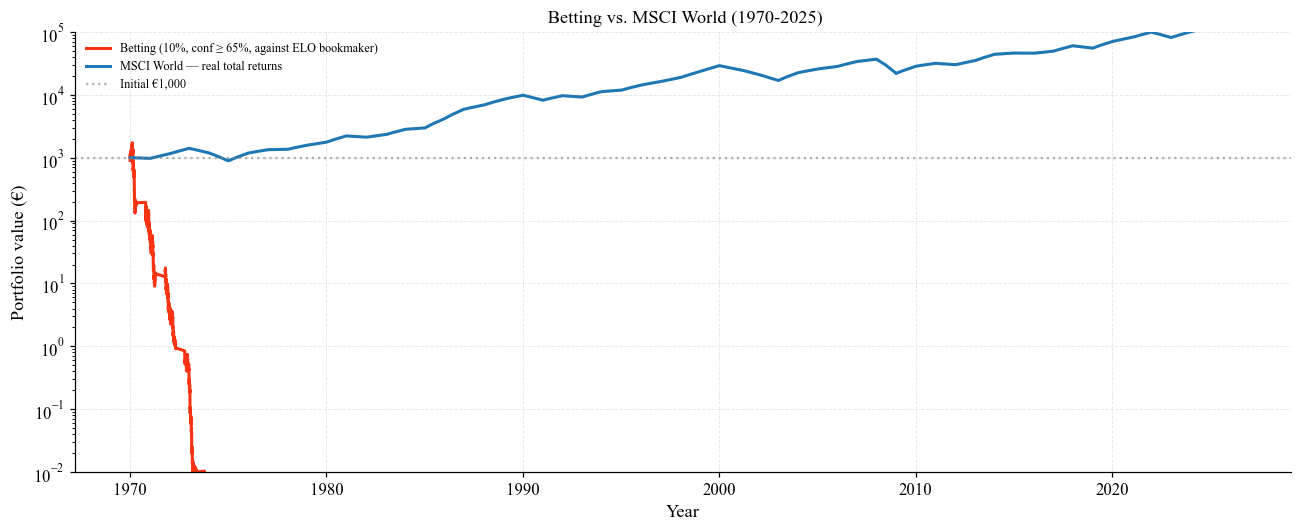

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(bets.gameDate, bets.bankroll, color="#f93414",
        label=f"Betting (10%, conf ≥ {int(CONFIDENCE_THRESHOLD*100)}%, against ELO bookmaker)",
        linewidth=2)
ax.plot(bets.gameDate, bets.msci, color="#1f77b4",
        label="MSCI World — real total returns", linewidth=2)
ax.axhline(INITIAL_CAPITAL, color="gray", linestyle=":", alpha=0.6, label="Initial €1,000")

ax.set_yscale("log")
ax.set_ylim(0.01,1e5)
ax.set_title(" Betting vs. MSCI World (1970-2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Portfolio value (€)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

hahahaha well betting is no good idea. Or as a poet would say: "Too much greed leaves you on the street"

## 8. Saving

In [9]:
out_dir = Path('..') / 'data' / 'processed'
metrics_df.to_csv(out_dir / 'backtest_metrics.csv', index=False)
preds_df.to_parquet(out_dir / 'backtest_predictions.parquet', index=False)
print('Saved')

Saved
